# Decision Tree
---
### Author :  Muhammad Ali Saagar

**Python Developer • Data Science • AI/ML Engineer**

#### 🔗 Connect With Me

[![GitHub](https://img.shields.io/badge/GitHub-Profile-181717?style=for-the-badge\&logo=github)](https://github.com/AliMuhammad78)
[![LinkedIn](https://img.shields.io/badge/LinkedIn-Profile-0A66C2?style=for-the-badge\&logo=linkedin)](https://www.linkedin.com/in/muhammad-ali-91294a290)
[![Kaggle](https://img.shields.io/badge/Kaggle-Profile-20BEFF?style=for-the-badge\&logo=kaggle)](https://www.kaggle.com/ali98muhammad45)
[![YouTube](https://img.shields.io/badge/YouTube-Channel-FF0000?style=for-the-badge\&logo=youtube)](https://www.youtube.com/@TechyBits20121)
[![Email](https://img.shields.io/badge/Email-Contact-D14836?style=for-the-badge\&logo=gmail)](mailto:alisaagar86@gmail.com)

### Acknowledgement

> Most of the examples in this notebook are based on the excellent tutorials by **Dr. Muhammad Aammar Tufail (Codanics)**. I sincerely thank him for sharing his knowledge and practical examples.

 [![GitHub](https://img.shields.io/badge/GitHub-Profile-181717?style=for-the-badge\&logo=github)](https://github.com/AammarTufail)
[![LinkedIn](https://img.shields.io/badge/LinkedIn-Profile-0A66C2?style=for-the-badge\&logo=linkedin)](https://www.linkedin.com/in/dr-muhammad-aammar-tufail-02471213b/)
[![Kaggle](https://img.shields.io/badge/Kaggle-Profile-20BEFF?style=for-the-badge\&logo=kaggle)](https://www.kaggle.com/muhammadaammartufail)
[![YouTube](https://img.shields.io/badge/YouTube-Channel-FF0000?style=for-the-badge\&logo=youtube)](https://www.youtube.com/@codanics)

---
# Decision Tree
Decision Tree is a type of **supervised learning algorithm** mostly used in **classification problems**, but it also works for **regression** with continuous outputs.

## Key Idea
- Splits data into smaller subsets based on feature values  
- Forms a **tree-like structure** of decisions  
- Final output is obtained at the **leaf nodes**  

## Structure
- Internal nodes → represent features  
- Branches → represent decision rules  
- Leaf nodes → represent final outcome  

<img src="https://miro.medium.com/v2/resize:fit:1400/0*g4fblQAEbjS_arPX.png" alt="Decision Tree Image" style="width: 500px" />

## Basic Terms
- Root Node → starting point of the tree  
- Decision Node → node where a split occurs  
- Leaf Node → final output node  
- Split → dividing data based on a condition  
- Depth → number of levels in the tree  

## Important Formulas

### Entropy
$$
Entropy = - \sum p_i \log_2(p_i)
$$

### Information Gain
$$
IG = Entropy(parent) - \sum \left( \frac{n_{child}}{n_{parent}} \times Entropy(child) \right)
$$

### Gini Index
$$
Gini = 1 - \sum p_i^2
$$

## Key Points
- Works with both **categorical and numerical data**  
- No need for feature scaling  
- Can capture **non-linear relationships**  
- Prone to **overfitting** if tree is deep  

## Advantages
- Easy to understand and visualize  
- Handles both classification and regression  
- Requires less data preprocessing  

## Limitations
- Overfitting problem  
- Sensitive to small changes in data  
- Can become complex with deep trees  

---

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

In [2]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# see null values 
df.isnull().sum().sort_values(ascending = False)

deck           688
age            177
embarked         2
embark_town      2
survived         0
pclass           0
sex              0
sibsp            0
parch            0
fare             0
class            0
who              0
adult_male       0
alive            0
alone            0
dtype: int64

In [4]:
df.drop('deck', axis=1, inplace=True)

#impute missing values of age, and fare using median
imputer = SimpleImputer(strategy='median')
df[['age', 'fare']] = imputer.fit_transform(df[['age', 'fare']])

# impute missing values of embark and embarked_town using mode
imputer = SimpleImputer(strategy='most_frequent')
df[['embark_town', 'embarked']] = imputer.fit_transform(df[['embark_town', 'embarked']])

In [5]:
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  embark_town  891 non-null    object  
 12  alive        891 non-null    object  
 13  alone        891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), object(5)
memory usage: 79.4+ KB


In [7]:
# encoding categorical features
le = LabelEncoder()
for col in df.select_dtypes(include = ['category' , 'object']):
    df[col] = le.fit_transform(df[col])
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,2,1,True,2,0,False
1,1,1,0,38.0,1,0,71.2833,0,0,2,False,0,1,False
2,1,3,0,26.0,0,0,7.9250,2,2,2,False,2,1,True
3,1,1,0,35.0,1,0,53.1000,2,0,2,False,2,1,False
4,0,3,1,35.0,0,0,8.0500,2,2,1,True,2,0,True


In [8]:
X = df.drop(['survived', 'alive'], axis=1)
y = df['survived']
# split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

[[92 13]
 [19 55]]
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



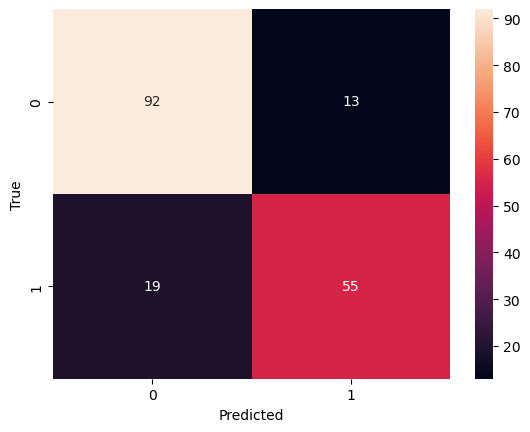

In [9]:
# create and train teh model with pred
model = DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=5)
model.fit(X_train, y_train)

# predict the model
y_pred = model.predict(X_test)
# evaluate the model
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# plot confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [10]:
# save the decision tree classifier
from sklearn.tree import export_graphviz
export_graphviz(model, out_file='../Regression/models/03_Decision_Tree.dot', feature_names=X.columns, filled=True, rounded=True)

## Decision Tree regressor 

In [ ]:
# Titanic Decision Tree Regressor Example

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

import seaborn as sns
df = sns.load_dataset('titanic')


df.drop('deck', axis=1, inplace=True)

# Impute missing numerical values ('age', 'fare') with median
num_imputer = SimpleImputer(strategy='median')
df[['age', 'fare']] = num_imputer.fit_transform(df[['age', 'fare']])

# Impute missing categorical values ('embark_town', 'embarked') with mode
cat_imputer = SimpleImputer(strategy='most_frequent')
df[['embark_town', 'embarked']] = cat_imputer.fit_transform(df[['embark_town', 'embarked']])

# Encode categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include=['object', 'category']):
    df[col] = le.fit_transform(df[col])

# Select features (drop 'fare' since it's the target)
X = df.drop('fare', axis=1)
y = df['fare']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the Decision Tree Regressor
model = DecisionTreeRegressor(criterion='squared_error', random_state=42, max_depth=5)
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate the model using RMSE
rmse = mean_squared_error(y_test, y_pred)
print("Root Mean Squared Error (RMSE):", rmse)

 
results = pd.DataFrame({'Actual Fare': y_test, 'Predicted Fare': y_pred})
print(results.head())

Root Mean Squared Error (RMSE): 1523.1518822153087
     Actual Fare  Predicted Fare
709      15.2458       16.704000
439      10.5000       12.197500
840       7.9250        8.764894
720      33.0000       27.749436
39       11.2417       16.704000
